<a href="https://colab.research.google.com/github/seonilj/eeg-alpha-erd-analysis/blob/main/notebooks/01_eeg_loading_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#EEG Data Loading & Initial Visualization
##EEG 데이터 로딩 및 초기 시각화
---

#Goal
Load the PhysioNet EEG Motor Imagery dataset, inspect its basic structure, apply the international electrode montage, and visualize the raw EEG recordings.

This notebook prepares the dataset for Alpha Event-Related Desynchronization (ERD) analysis performed in later notebooks.

In [ ]:
# ==============================================================================
# Step 1: Environment Setup
# ==============================================================================

%pip install mne matplotlib

import mne
import matplotlib.pyplot as plt
import os

print("MNE version:", mne.__version__)
print("Environment ready.")

MNE version: 1.12.1
Environment ready.


In [ ]:
# ==============================================================================
# Step 2: Download PhysioNet EEG Dataset
# ==============================================================================

subject = 1

# Run 4
# Motor imagery:
# Left fist / Right fist imagination
runs = [4]

raw_files = mne.datasets.eegbci.load_data(subject, runs)

raw = mne.io.read_raw_edf(
    raw_files[0],
    preload=True
)

print(raw)

Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>


In [ ]:
# ==============================================================================
# Step 3: Standardize EEG Channel Names
# ==============================================================================

# Remove unnecessary trailing dots
mapping = {
    ch: ch.rstrip(".")
    for ch in raw.ch_names
}

raw.rename_channels(mapping)

print("Example channels:")
print(raw.ch_names[:10])

Example channels:
['Fc5', 'Fc3', 'Fc1', 'Fcz', 'Fc2', 'Fc4', 'Fc6', 'C5', 'C3', 'C1']


In [ ]:
# ==============================================================================
# Step 4: Apply Standard 10-05 Electrode Montage
# ==============================================================================

# Linking the scalp positions of each electrode to allow for subsequent spatial analysis and visualization
montage = mne.channels.make_standard_montage("standard_1005")

raw.set_montage(
    montage,
    match_case=False
)

print("Standard electrode positions assigned.")

Standard electrode positions assigned.


In [ ]:
# ==============================================================================
# Step 5: Inspect Recording Information
# ==============================================================================

print("\nRecording Information")
print("---------------------")

print(f"Channels : {len(raw.ch_names)}")
print(f"Sampling Rate : {raw.info['sfreq']} Hz")

duration = raw.n_times / raw.info["sfreq"]

print(f"Duration : {duration:.2f} seconds")
print(f"EEG Channels : {raw.info['nchan']}")


Recording Information
---------------------
Channels : 64
Sampling Rate : 160.0 Hz
Duration : 125.00 seconds
EEG Channels : 64


In [ ]:
# ==============================================================================
# Step 6: Create Output Directory
# ==============================================================================

output_dir = "./figures"

os.makedirs(
    output_dir,
    exist_ok=True
)

print("Output folder ready.")

Output folder ready.


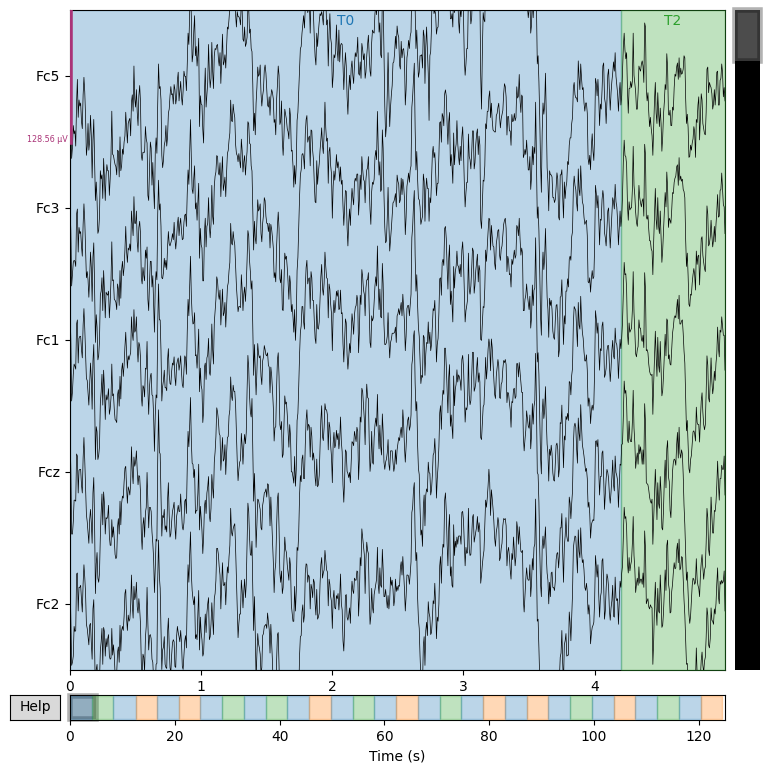

Successfully saved 'raw_eeg.png' into the Colab file system.


In [ ]:
# ==============================================================================
# Step 7: Visualize Raw EEG Signals
# ==============================================================================

# Visualize the first 5 seconds of the top 5 EEG channels
fig = raw.plot(
    n_channels=5,
    duration=5,
    scalings="auto",
    show=False
)

# Save the figure 'raw_eeg.png'
fig.savefig(
    os.path.join(output_dir, "raw_eeg.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Successfully saved 'raw_eeg.png' into the Colab file system.")

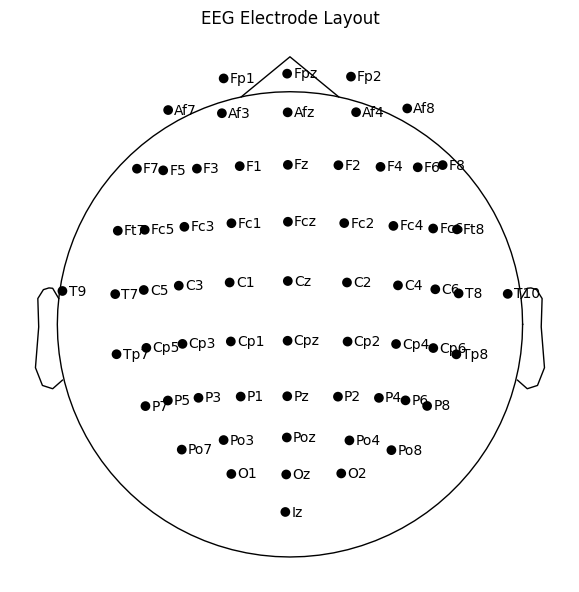

Successfully saved 'sensor_layout.png' into the Colab file system.


In [ ]:
# ==============================================================================
# Step 8: Visualize Electrode Locations
# ==============================================================================

# Create a dedicated matplotlib figure object
fig, ax = plt.subplots(figsize=(6, 6))

# Execute standalone MNE visualization pipeline mapped directly onto the axes layout
# Set show=False so it populates the canvas before rendering
mne.viz.plot_sensors(
    raw.info,
    kind="topomap",
    show_names=True,
    axes=ax,
    show=False
)

plt.title("EEG Electrode Layout")

plt.tight_layout()

# Save the figure "sensor_layout.png" into the existing folder
fig.savefig(
    os.path.join(output_dir, "sensor_layout.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Successfully saved 'sensor_layout.png' into the Colab file system.")

In [ ]:
# ==============================================================================
# Step 9: Inspect Experimental Events
# ==============================================================================

events, event_id = mne.events_from_annotations(raw)

print("Event dictionary")
print(event_id)

print("\n First five events")
print(events[:5])

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Event dictionary
{np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}

 First five events
[[   0    0    1]
 [ 672    0    3]
 [1328    0    1]
 [2000    0    2]
 [2656    0    1]]
